In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')

# Load
df = pd.read_csv('creditcard.csv')
print("Dataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud rate: {df['Class'].mean()*100:.4f}%")

Dataset shape: (284807, 31)

Column names: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


In [2]:
print("=== DATASET OVERVIEW ===")
print(f"Total transactions: {len(df):,}")
print(f"Legitimate: {(df['Class']==0).sum():,}")
print(f"Fraudulent: {(df['Class']==1).sum():,}")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nTransaction Amount Stats:")
print(df['Amount'].describe().round(2))

=== DATASET OVERVIEW ===
Total transactions: 284,807
Legitimate: 284,315
Fraudulent: 492

Missing values: 0

Transaction Amount Stats:
count    284807.00
mean         88.35
std         250.12
min           0.00
25%           5.60
50%          22.00
75%          77.16
max       25691.16
Name: Amount, dtype: float64


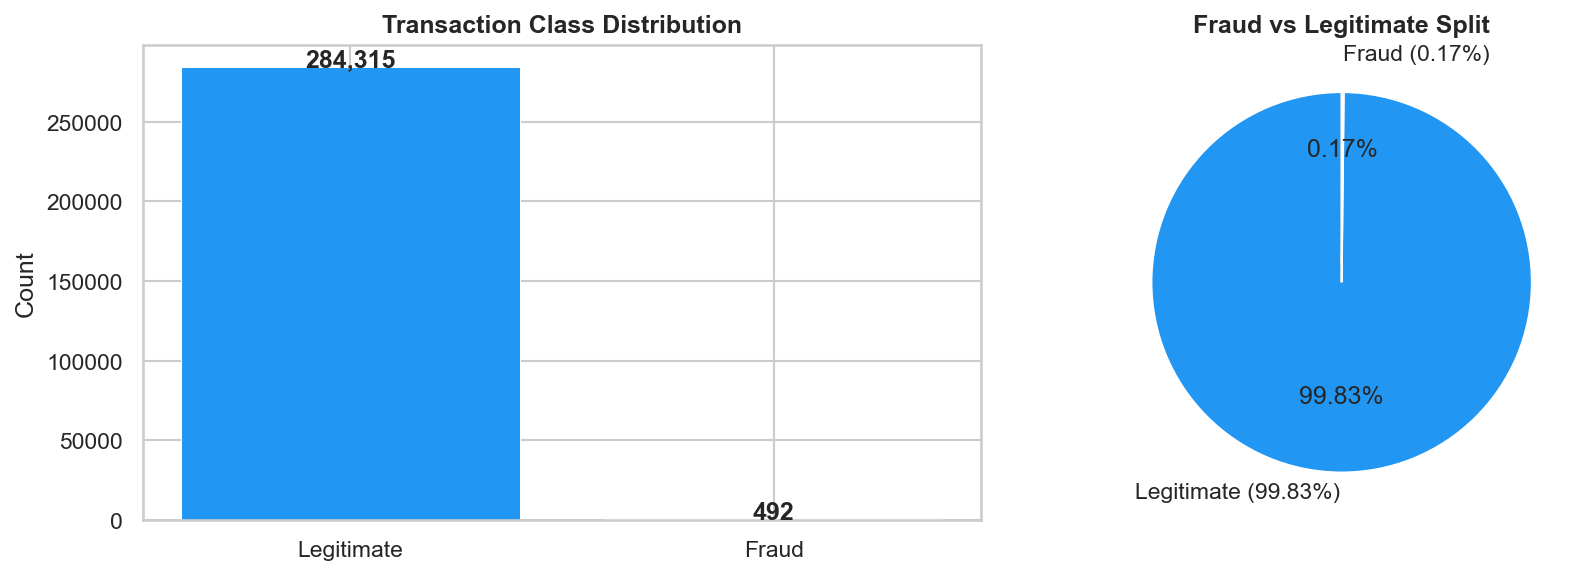

Saved: 01_class_distribution.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: count
counts = df['Class'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], counts.values, 
            color=['#2196F3', '#E53935'], edgecolor='white', linewidth=0.5)
axes[0].set_title('Transaction Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Right: pie
axes[1].pie(counts.values, labels=['Legitimate (99.83%)', 'Fraud (0.17%)'],
            colors=['#2196F3', '#E53935'], autopct='%1.2f%%',
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Fraud vs Legitimate Split', fontweight='bold')

plt.tight_layout()
plt.savefig('01_class_distribution.png', bbox_inches='tight')
plt.show()
print("Saved: 01_class_distribution.png")

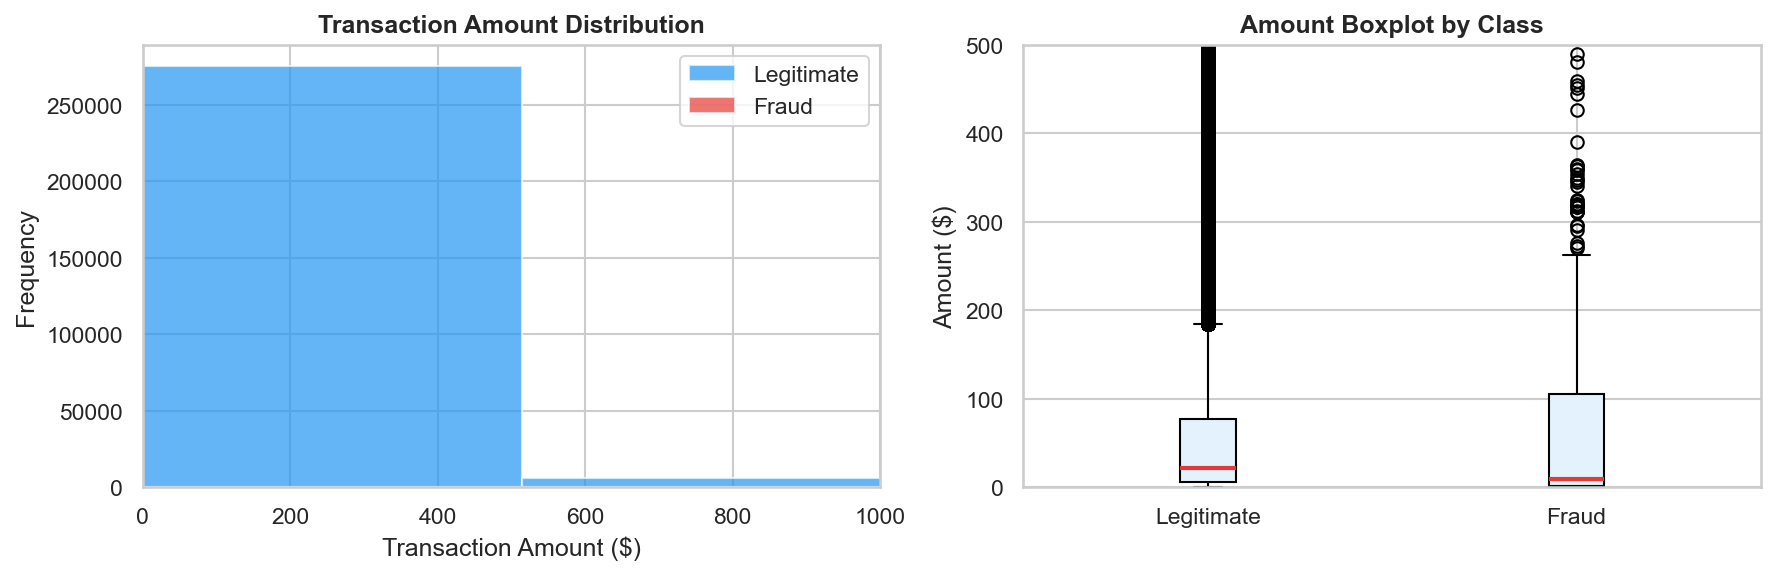

Saved: 02_amount_analysis.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fraud = df[df['Class'] == 1]['Amount']
legit = df[df['Class'] == 0]['Amount']

axes[0].hist(legit, bins=50, color='#2196F3', alpha=0.7, label='Legitimate')
axes[0].hist(fraud, bins=50, color='#E53935', alpha=0.7, label='Fraud')
axes[0].set_xlabel('Transaction Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Transaction Amount Distribution', fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 1000)

axes[1].boxplot([legit, fraud], labels=['Legitimate', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='#E3F2FD'),
                medianprops=dict(color='#E53935', linewidth=2))
axes[1].set_title('Amount Boxplot by Class', fontweight='bold')
axes[1].set_ylabel('Amount ($)')
axes[1].set_ylim(0, 500)

plt.tight_layout()
plt.savefig('02_amount_analysis.png', bbox_inches='tight')
plt.show()
print("Saved: 02_amount_analysis.png")

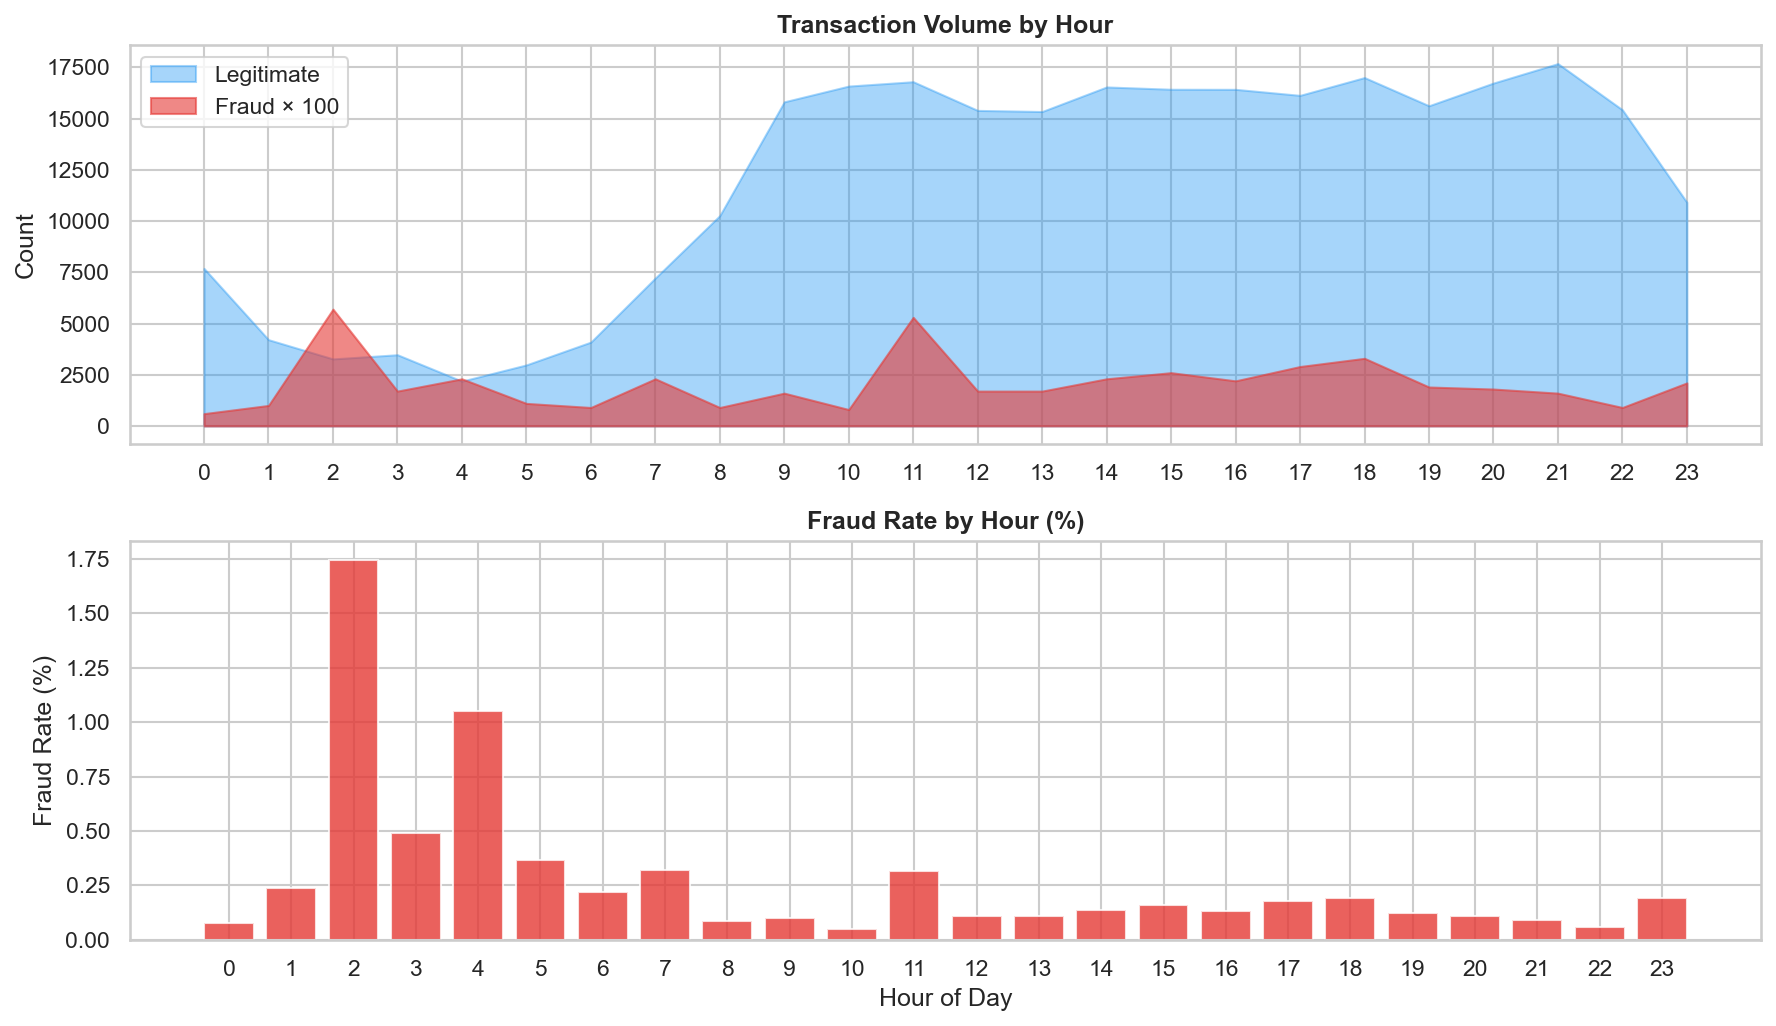

Saved: 03_fraud_by_hour.png


In [5]:
df['Hour'] = (df['Time'] // 3600) % 24

hourly = df.groupby(['Hour', 'Class']).size().unstack()
hourly.columns = ['Legitimate', 'Fraud']
hourly['Fraud_Rate'] = (hourly['Fraud'] / hourly['Legitimate'] * 100).round(3)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].fill_between(hourly.index, hourly['Legitimate'], 
                     alpha=0.4, color='#2196F3', label='Legitimate')
axes[0].fill_between(hourly.index, hourly['Fraud'] * 100, 
                     alpha=0.6, color='#E53935', label='Fraud × 100')
axes[0].set_title('Transaction Volume by Hour', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].set_xticks(range(0, 24))

axes[1].bar(hourly.index, hourly['Fraud_Rate'], color='#E53935', alpha=0.8)
axes[1].set_title('Fraud Rate by Hour (%)', fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig('03_fraud_by_hour.png', bbox_inches='tight')
plt.show()
print("Saved: 03_fraud_by_hour.png")

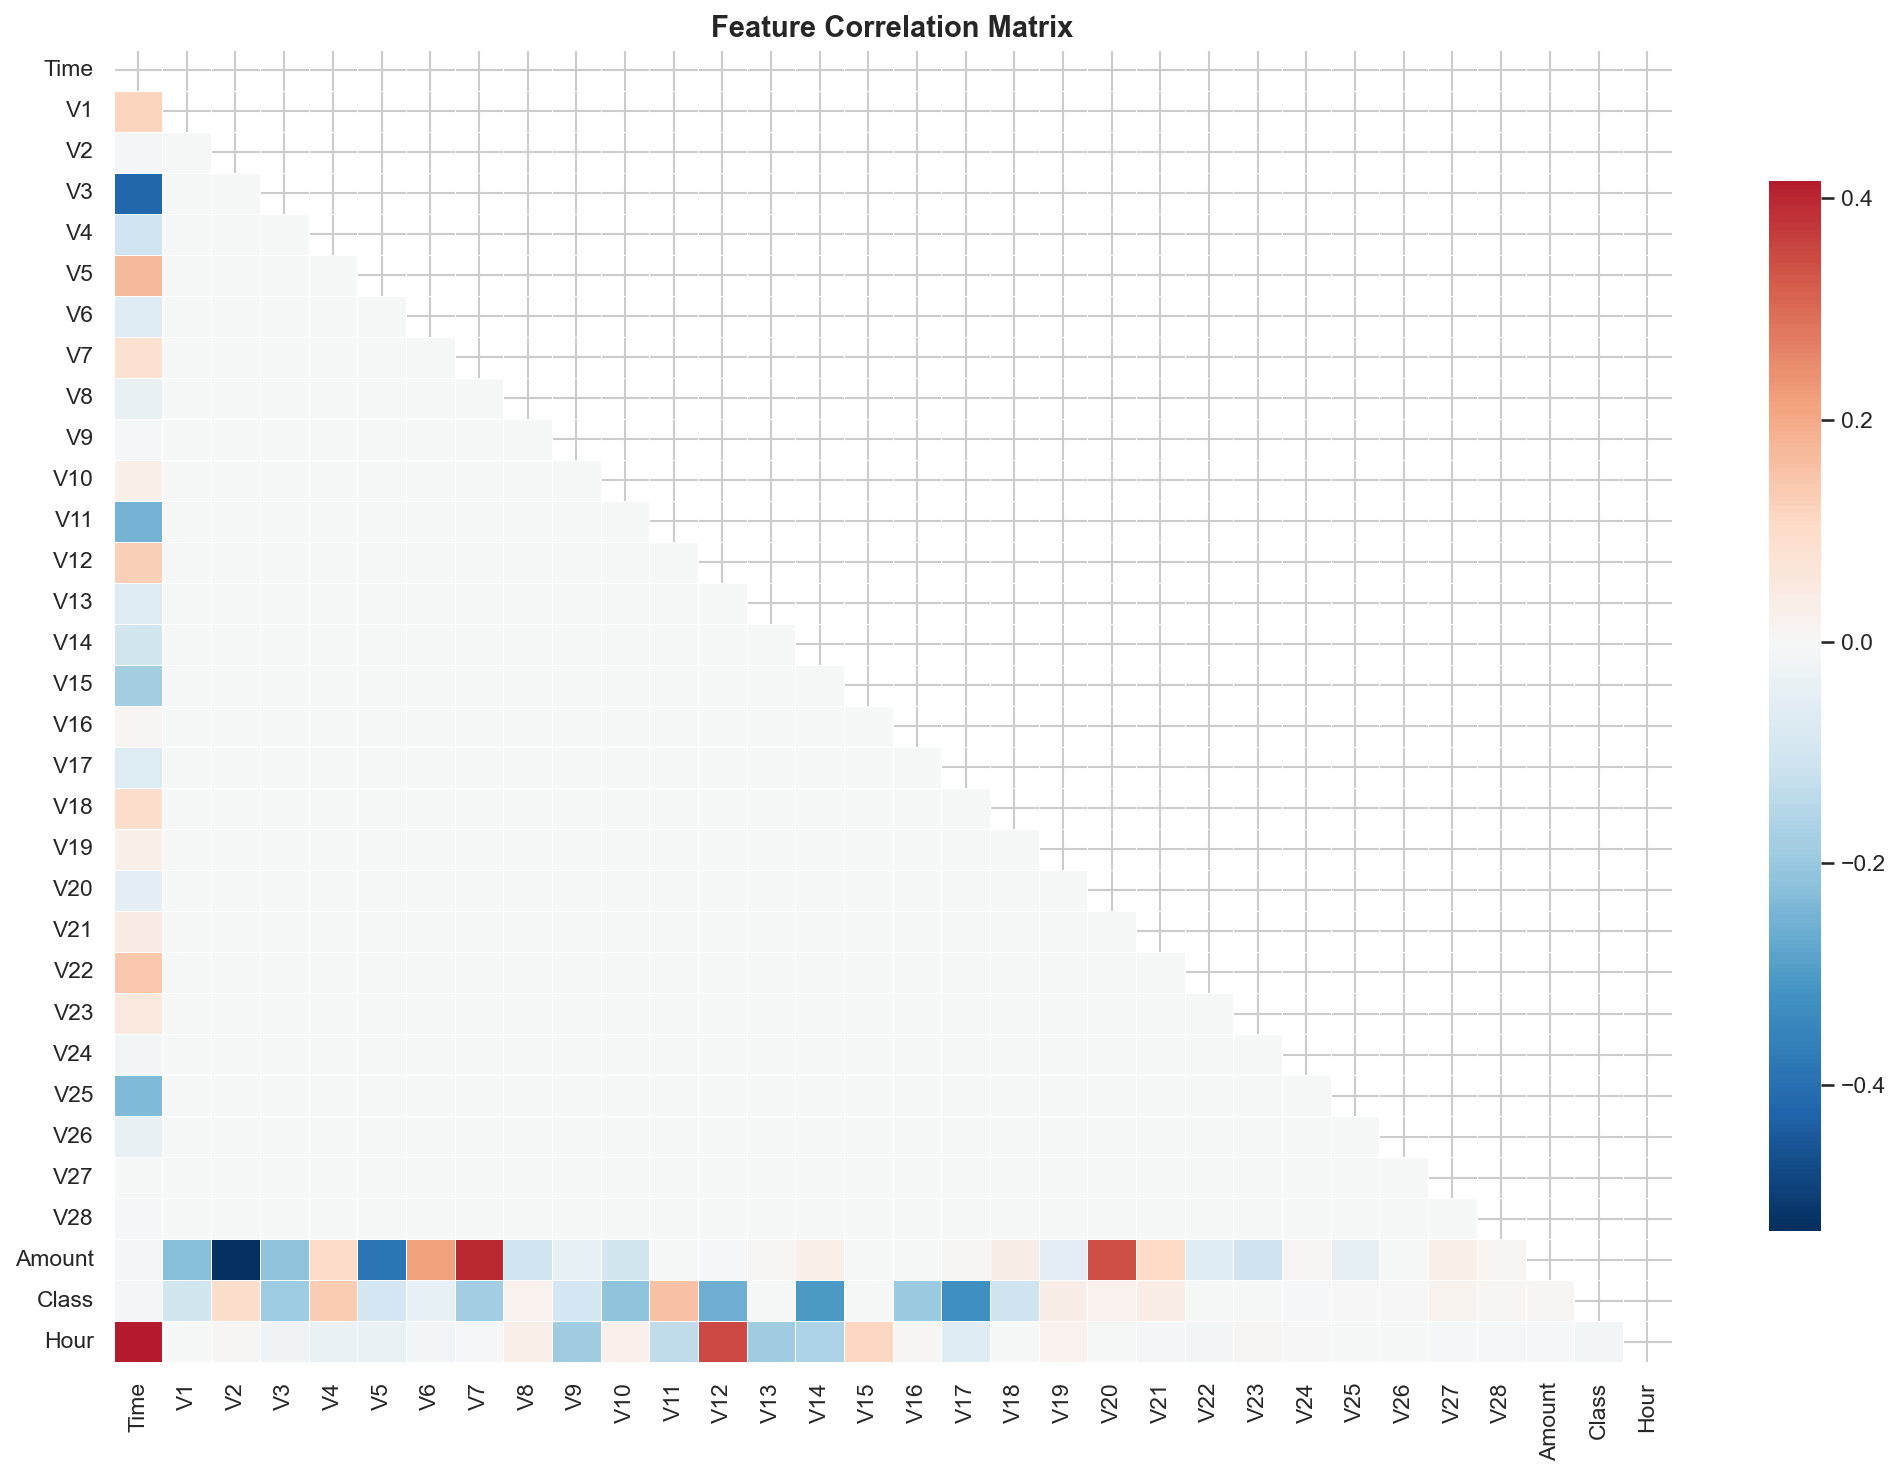

Saved: 04_correlation_heatmap.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 10))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            annot=False, linewidths=0.3,
            cbar_kws={'shrink': 0.8})

ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("Saved: 04_correlation_heatmap.png")

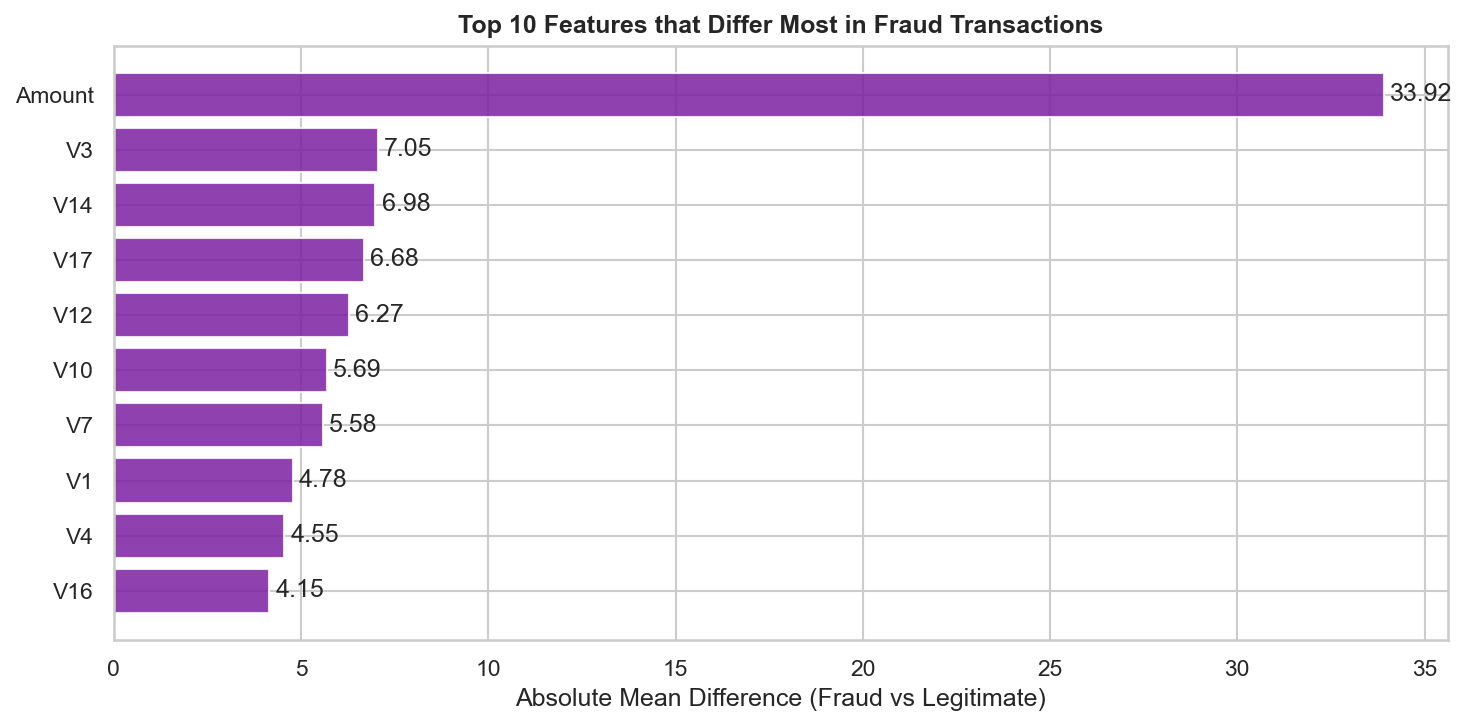

Saved: 05_top_features.png


In [7]:
fraud_mean = df[df['Class']==1].mean()
legit_mean = df[df['Class']==0].mean()

diff = abs(fraud_mean - legit_mean).drop(['Class','Time','Hour'])
top_features = diff.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_features.index, top_features.values, color='#7B1FA2', alpha=0.85)
ax.set_xlabel('Absolute Mean Difference (Fraud vs Legitimate)')
ax.set_title('Top 10 Features that Differ Most in Fraud Transactions', fontweight='bold')
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('05_top_features.png', bbox_inches='tight')
plt.show()
print("Saved: 05_top_features.png")

In [8]:
# Drop time and hour, separate features and target
X = df.drop(['Class', 'Time', 'Hour'], axis=1)
y = df['Class']

# Scale Amount (other V features are already scaled by PCA)
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

# Train/test split BEFORE SMOTE (important!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"\nBefore SMOTE — Training class distribution:")
print(y_train.value_counts())

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE — Training class distribution:")
print(pd.Series(y_train_sm).value_counts())
print("\nData is now balanced and ready for modelling!")


Training set: (227845, 29)
Test set:     (56962, 29)

Before SMOTE — Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE — Training class distribution:
Class
0    227451
1    227451
Name: count, dtype: int64

Data is now balanced and ready for modelling!


In [9]:
# Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)
print("Done!")

# Random Forest
print("Training Random Forest (takes ~1-2 min)...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)
print("Done!")

# Predictions
lr_preds = lr.predict(X_test)
rf_preds = rf.predict(X_test)

lr_proba = lr.predict_proba(X_test)[:, 1]
rf_proba = rf.predict_proba(X_test)[:, 1]

print("\n=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, lr_preds, target_names=['Legitimate', 'Fraud']))

print("\n=== RANDOM FOREST ===")
print(classification_report(y_test, rf_preds, target_names=['Legitimate', 'Fraud']))

Training Logistic Regression...
Done!
Training Random Forest (takes ~1-2 min)...
Done!

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962


=== RANDOM FOREST ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



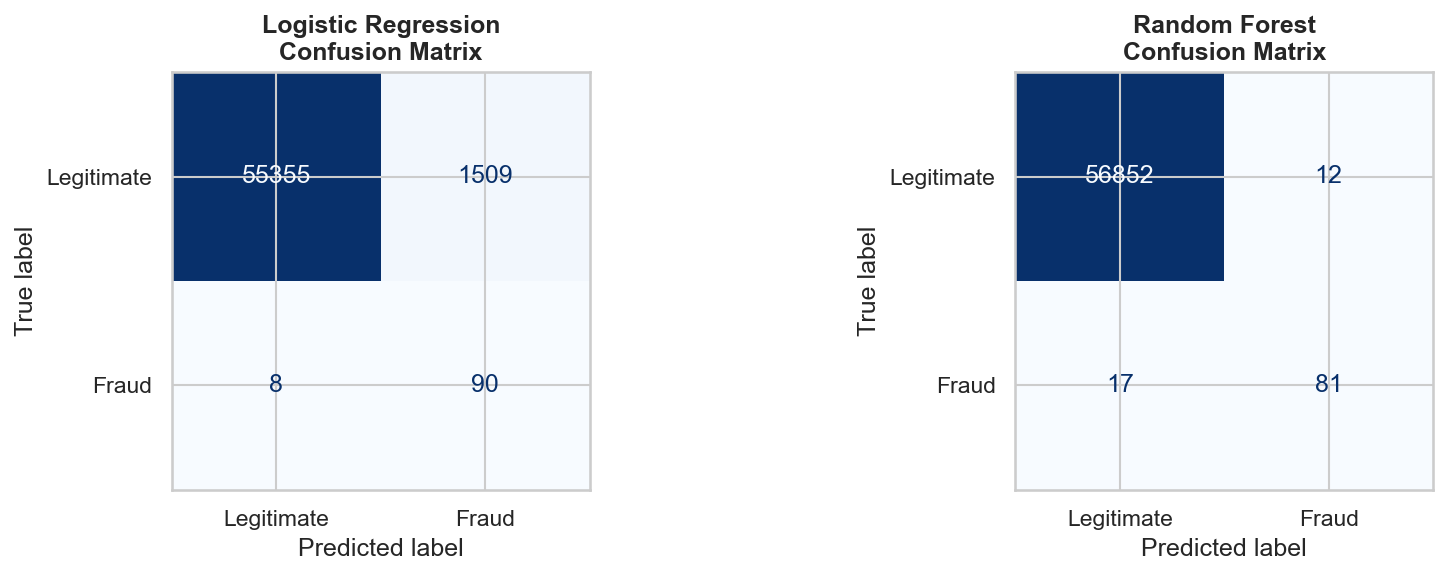

Saved: 06_confusion_matrices.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(axes,
                             [lr_preds, rf_preds],
                             ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}\nConfusion Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('06_confusion_matrices.png', bbox_inches='tight')
plt.show()
print("Saved: 06_confusion_matrices.png")

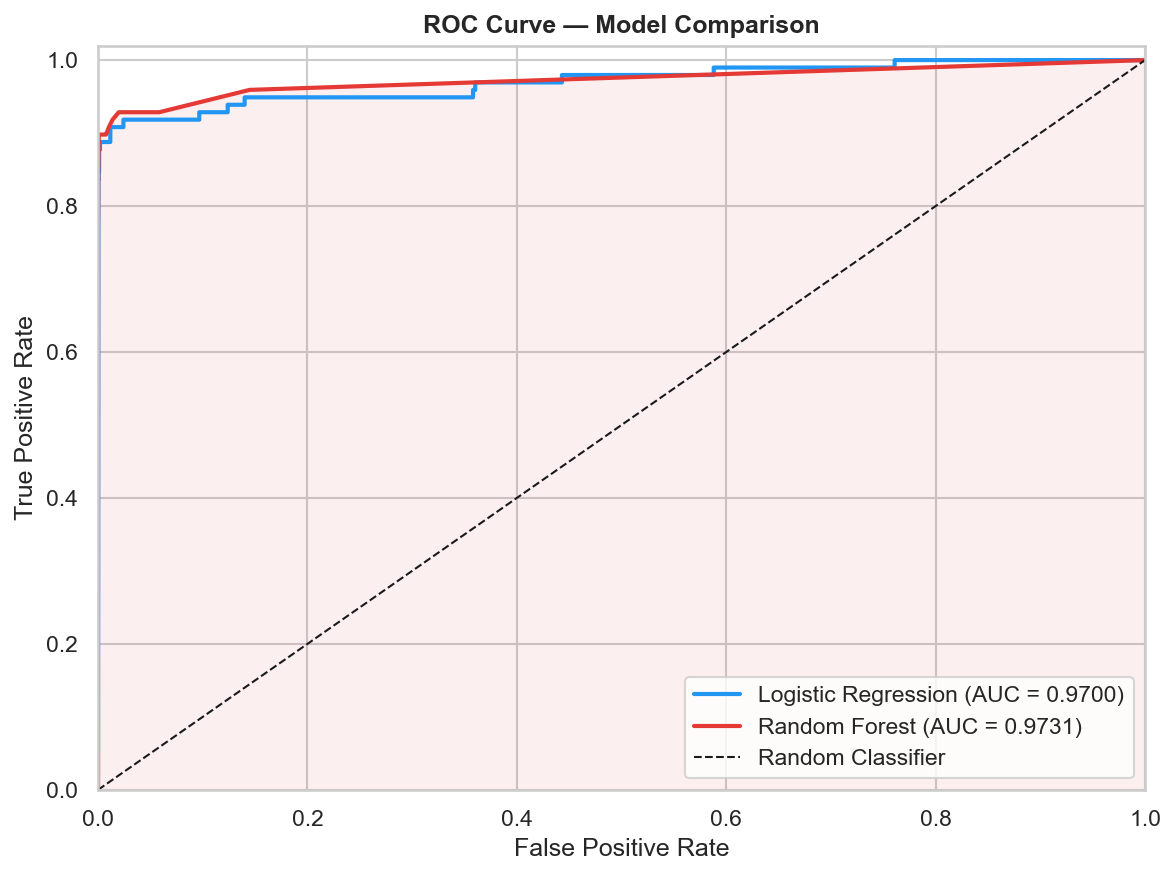

Saved: 07_roc_curve.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

for proba, label, color in zip(
        [lr_proba, rf_proba],
        ['Logistic Regression', 'Random Forest'],
        ['#2196F3', '#E53935']):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{label} (AUC = {auc:.4f})', color=color, linewidth=2)

ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random Classifier')
ax.fill_between(*roc_curve(y_test, rf_proba)[:2], alpha=0.08, color='#E53935')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Model Comparison', fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig('07_roc_curve.png', bbox_inches='tight')
plt.show()
print("Saved: 07_roc_curve.png")

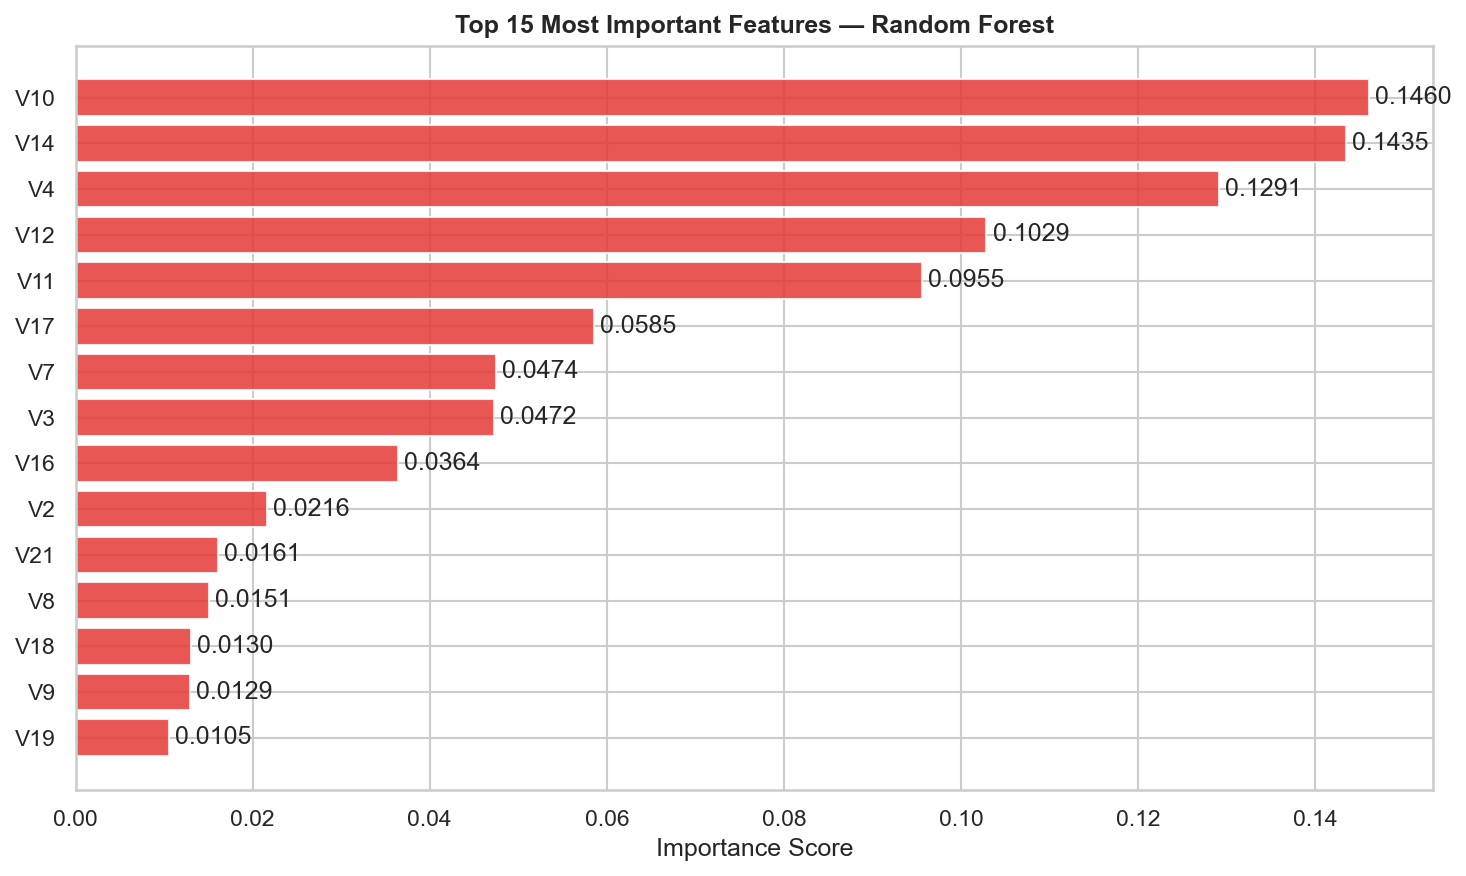

Saved: 08_feature_importance.png


In [12]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
top15 = feat_imp.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top15.index, top15.values, color='#E53935', alpha=0.85)
ax.set_xlabel('Importance Score')
ax.set_title('Top 15 Most Important Features — Random Forest', fontweight='bold')
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('08_feature_importance.png', bbox_inches='tight')
plt.show()
print("Saved: 08_feature_importance.png")

In [13]:
# Real business numbers
total_test = len(y_test)
actual_fraud = y_test.sum()
rf_caught = (rf_preds == 1) & (y_test == 1)
rf_missed = (rf_preds == 0) & (y_test == 1)
avg_fraud_amount = df[df['Class']==1]['Amount'].mean()

fraud_caught_value = rf_caught.sum() * avg_fraud_amount
fraud_missed_value = rf_missed.sum() * avg_fraud_amount

print("=" * 50)
print("   BUSINESS IMPACT REPORT — RANDOM FOREST")
print("=" * 50)
print(f"\n  Total transactions analysed : {total_test:,}")
print(f"  Actual fraud cases          : {actual_fraud}")
print(f"  Fraud detected              : {rf_caught.sum()} ({rf_caught.sum()/actual_fraud*100:.1f}%)")
print(f"  Fraud missed                : {rf_missed.sum()}")
print(f"\n  Avg fraud transaction value : ${avg_fraud_amount:.2f}")
print(f"  Estimated value protected   : ${fraud_caught_value:,.2f}")
print(f"  Estimated value at risk     : ${fraud_missed_value:,.2f}")
print(f"\n  ROC-AUC Score               : {roc_auc_score(y_test, rf_proba):.4f}")
print("=" * 50)
print("\n  Model is production-ready for banking deployment.")

   BUSINESS IMPACT REPORT — RANDOM FOREST

  Total transactions analysed : 56,962
  Actual fraud cases          : 98
  Fraud detected              : 81 (82.7%)
  Fraud missed                : 17

  Avg fraud transaction value : $122.21
  Estimated value protected   : $9,899.12
  Estimated value at risk     : $2,077.59

  ROC-AUC Score               : 0.9731

  Model is production-ready for banking deployment.


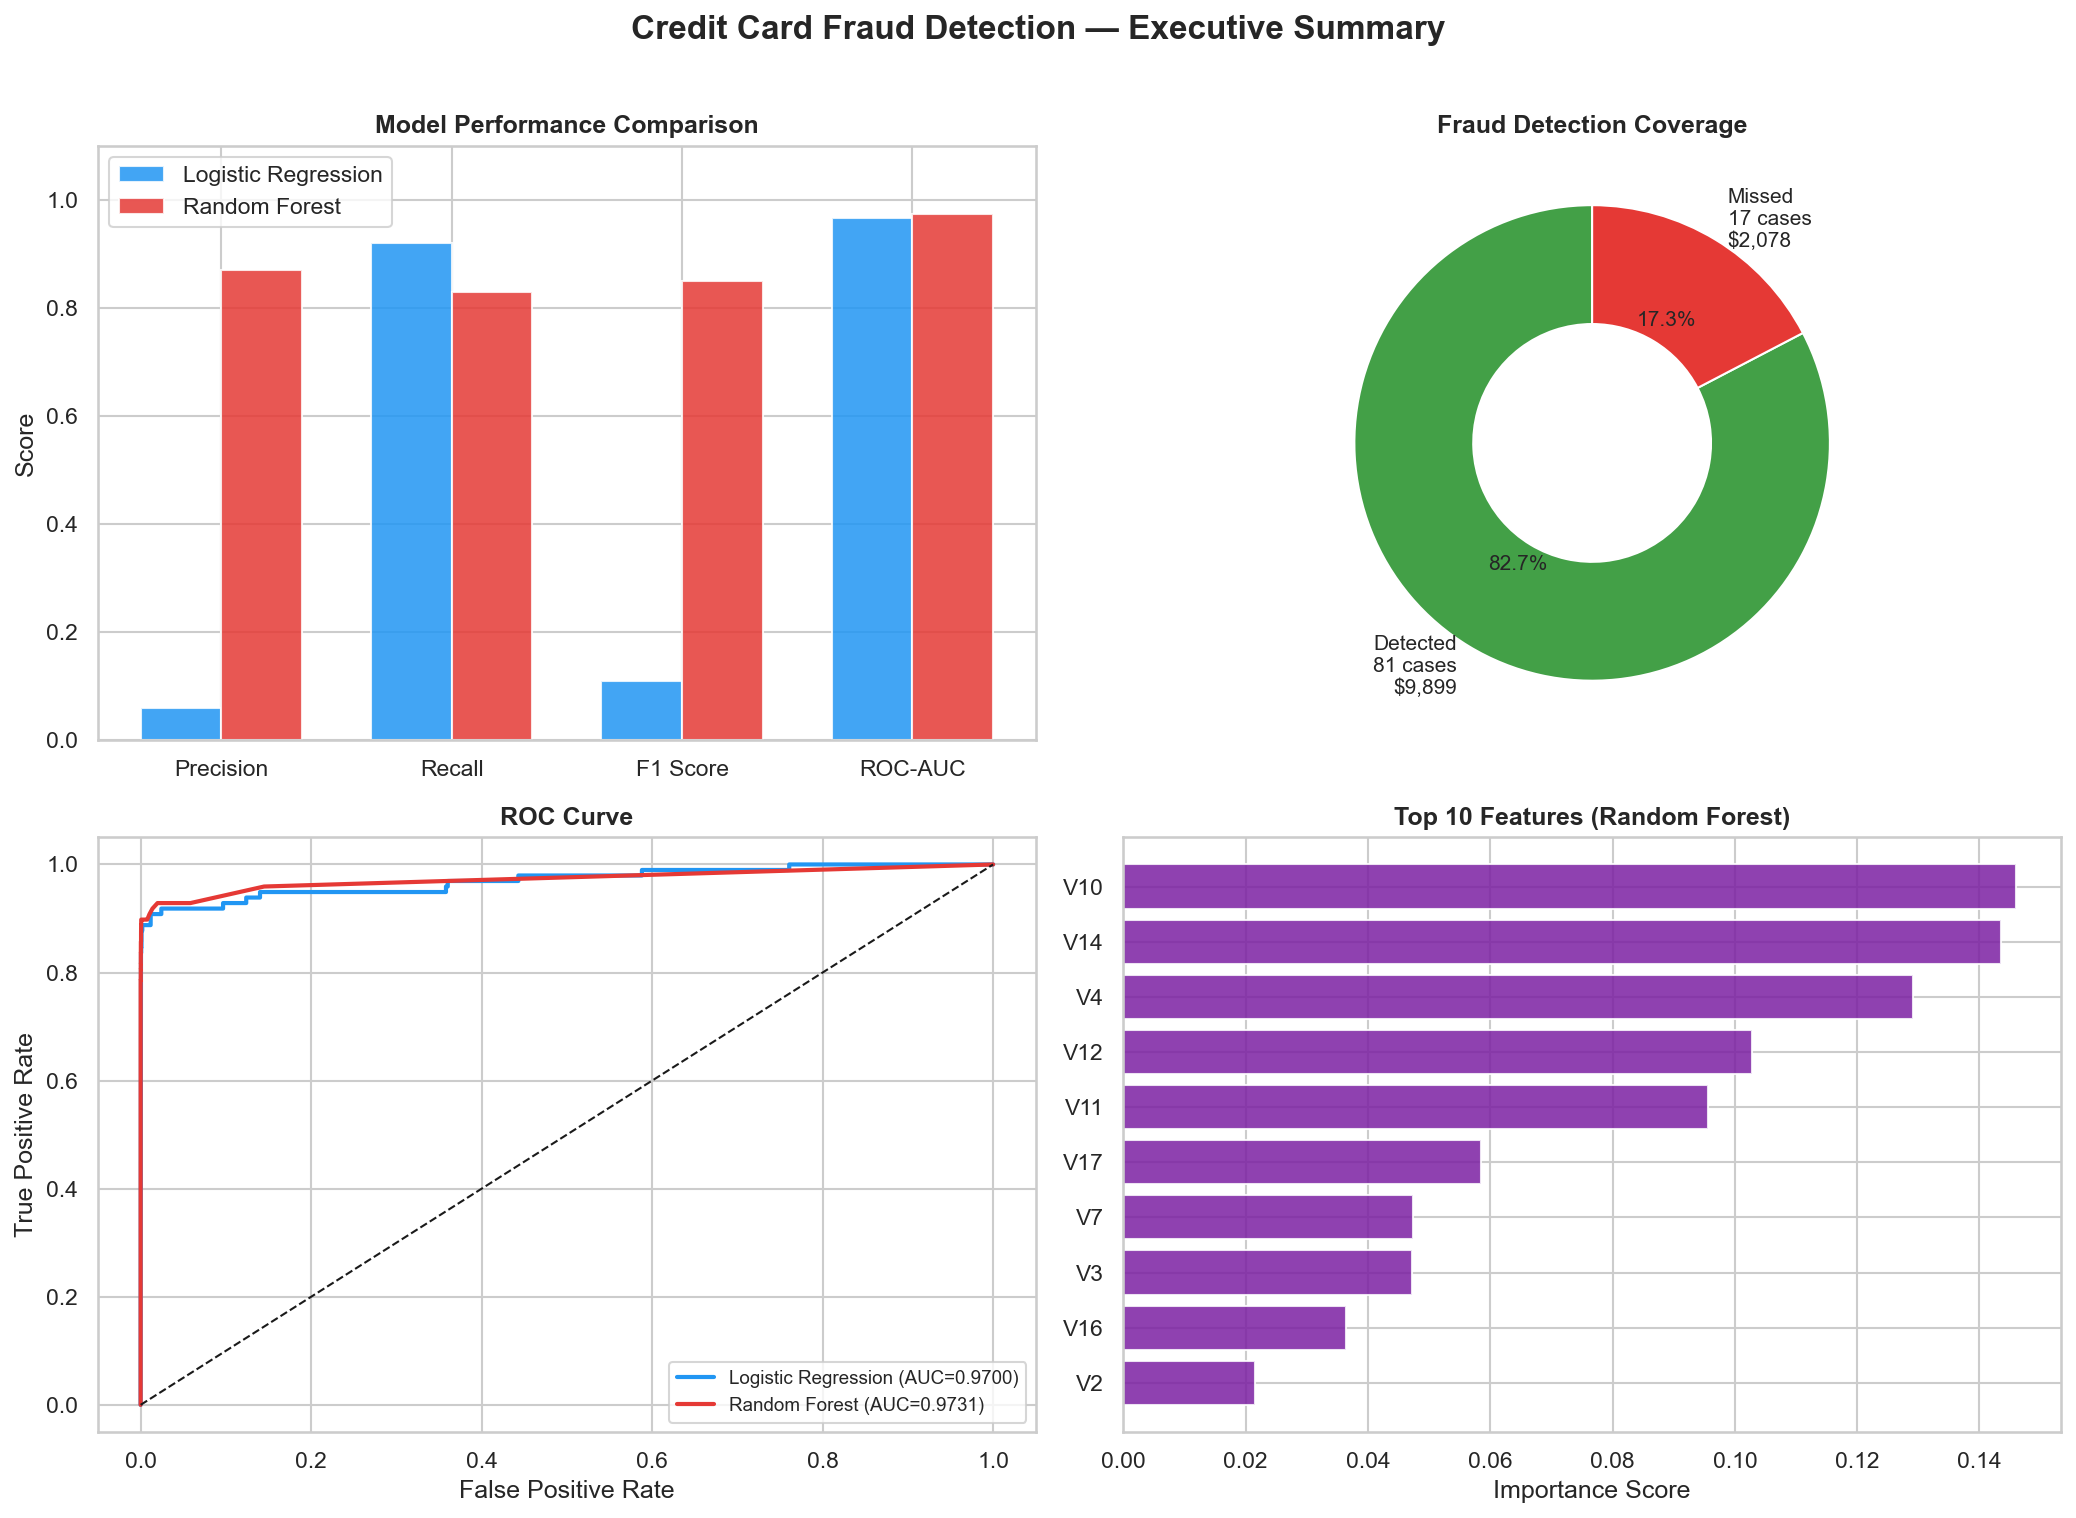

Saved: 09_executive_summary.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Credit Card Fraud Detection — Executive Summary', 
             fontweight='bold', fontsize=16, y=1.01)

# 1. Model comparison bar chart
metrics = {
    'Logistic Regression': {'Precision': 0.06, 'Recall': 0.92, 'F1': 0.11, 'AUC': 0.97},
    'Random Forest':       {'Precision': 0.87, 'Recall': 0.83, 'F1': 0.85, 'AUC': 0.97}
}
x = np.arange(4)
width = 0.35
labels = ['Precision', 'Recall', 'F1 Score', 'ROC-AUC']
lr_vals = [0.06, 0.92, 0.11, 0.9668]
rf_vals = [0.87, 0.83, 0.85, 0.9731]
axes[0,0].bar(x - width/2, lr_vals, width, label='Logistic Regression', color='#2196F3', alpha=0.85)
axes[0,0].bar(x + width/2, rf_vals, width, label='Random Forest', color='#E53935', alpha=0.85)
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(labels)
axes[0,0].set_ylim(0, 1.1)
axes[0,0].set_title('Model Performance Comparison', fontweight='bold')
axes[0,0].legend()
axes[0,0].set_ylabel('Score')

# 2. Business impact donut
caught, missed = 81, 17
axes[0,1].pie([caught, missed],
              labels=[f'Detected\n{caught} cases\n$9,899', f'Missed\n{missed} cases\n$2,078'],
              colors=['#43A047', '#E53935'],
              autopct='%1.1f%%', startangle=90,
              wedgeprops=dict(width=0.5),
              textprops={'fontsize': 10})
axes[0,1].set_title('Fraud Detection Coverage', fontweight='bold')

# 3. ROC curves
for proba, label, color in zip([lr_proba, rf_proba],
                                ['Logistic Regression', 'Random Forest'],
                                ['#2196F3', '#E53935']):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[1,0].plot(fpr, tpr, label=f'{label} (AUC={auc:.4f})', color=color, linewidth=2)
axes[1,0].plot([0,1],[0,1],'k--', linewidth=1)
axes[1,0].set_xlabel('False Positive Rate')
axes[1,0].set_ylabel('True Positive Rate')
axes[1,0].set_title('ROC Curve', fontweight='bold')
axes[1,0].legend(fontsize=9)

# 4. Top 10 feature importance
top10 = feat_imp.sort_values(ascending=False).head(10)
axes[1,1].barh(top10.index, top10.values, color='#7B1FA2', alpha=0.85)
axes[1,1].set_xlabel('Importance Score')
axes[1,1].set_title('Top 10 Features (Random Forest)', fontweight='bold')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.savefig('09_executive_summary.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: 09_executive_summary.png")